<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [9]:
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [10]:
file_url = "./cleaned_data/imputed_dataset.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,Unknown,...,20.0,15.0,10.0,5.0,0.0,0.0,Appropriate in length,Unknown,65000.0,7.0
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Unknown,65000.0,7.0
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,20.0,15.0,10.0,5.0,0.0,0.0,Appropriate in length,Easy,65000.0,7.0
3,4,I am learning to code,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Unknown,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,20.0,15.0,10.0,5.0,0.0,0.0,Too long,Easy,65000.0,7.0
4,5,I am a developer by profession,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Unknown,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,20.0,15.0,10.0,5.0,0.0,0.0,Too short,Easy,65000.0,7.0


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


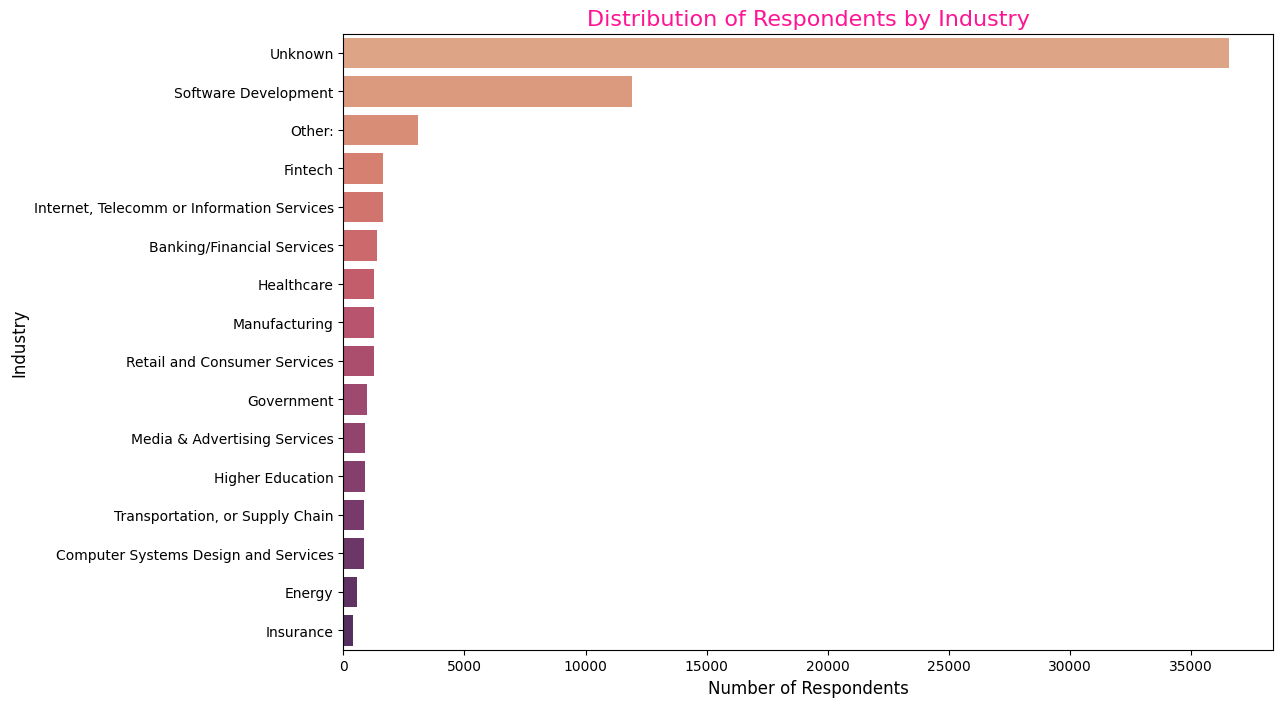

In [11]:
plt.figure(figsize=(12, 8))

industry_counts = df['Industry'].value_counts()

sns.barplot(x=industry_counts.values, y=industry_counts.index, palette='flare', hue=industry_counts.index, legend=False)

plt.title('Distribution of Respondents by Industry', fontsize=16, color='#FF1493')
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Industry', fontsize=12)

plt.show()

Without de Unknown category

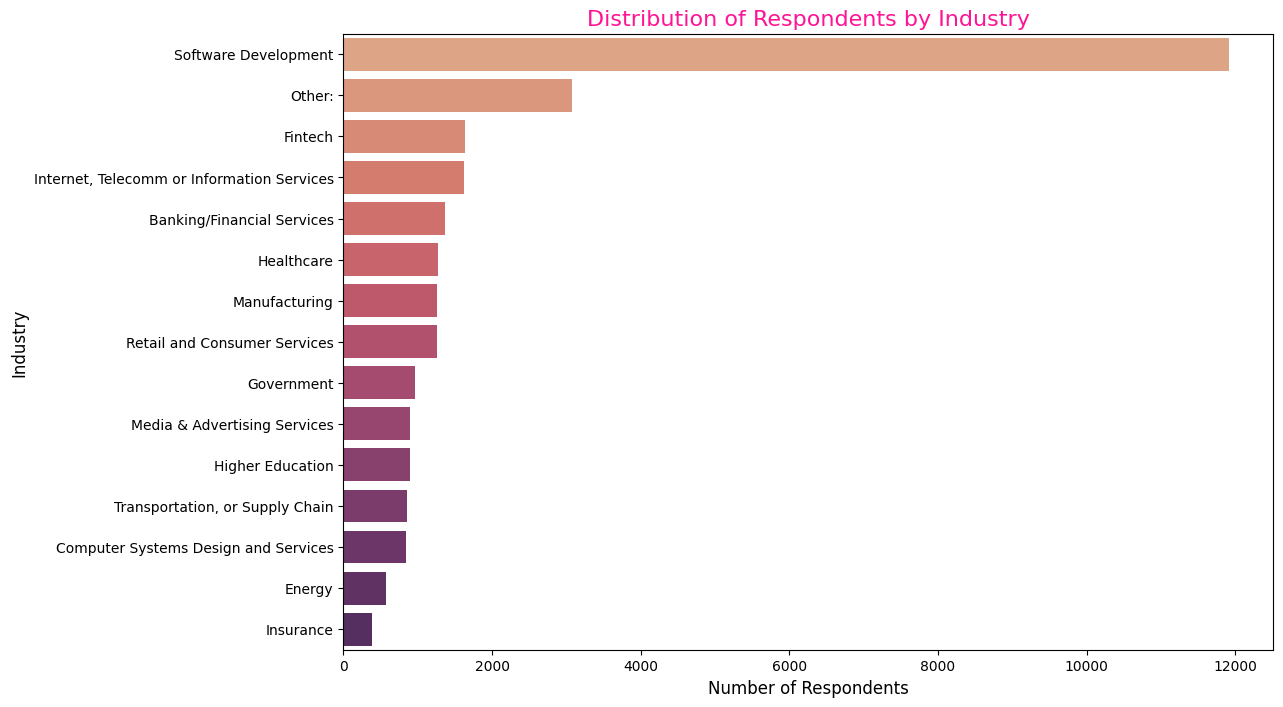

In [12]:
plt.figure(figsize=(12, 8))

industry_counts = df['Industry'].value_counts().drop('Unknown', errors='ignore')

sns.barplot(
    x=industry_counts.values, 
    y=industry_counts.index, 
    palette='flare', 
    hue=industry_counts.index, 
    legend=False
)

plt.title('Distribution of Respondents by Industry', fontsize=16, color='#FF1493')
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Industry', fontsize=12)

plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [13]:
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print(f"Mean Compensation: {mean_comp:.2f}")
print(f"Median Compensation: {median_comp:.2f}")
print(f"Standard Deviation: {std_comp:.2f}")

upper_threshold = mean_comp + (3 * std_comp)

high_comp_outliers = df[df['ConvertedCompYearly'] > upper_threshold]

print(f"\nNumber of outliers exceeding 3 standard deviations: {len(high_comp_outliers)}")
print(f"Upper Threshold Value: {upper_threshold:.2f}")

Mean Compensation: 72576.36
Median Compensation: 65000.00
Standard Deviation: 112220.68

Number of outliers exceeding 3 standard deviations: 194
Upper Threshold Value: 409238.40


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Interquartile Range (IQR): 0.0
Lower Bound: 65000.0
Upper Bound: 65000.0
Total number of outliers (IQR method): 23398


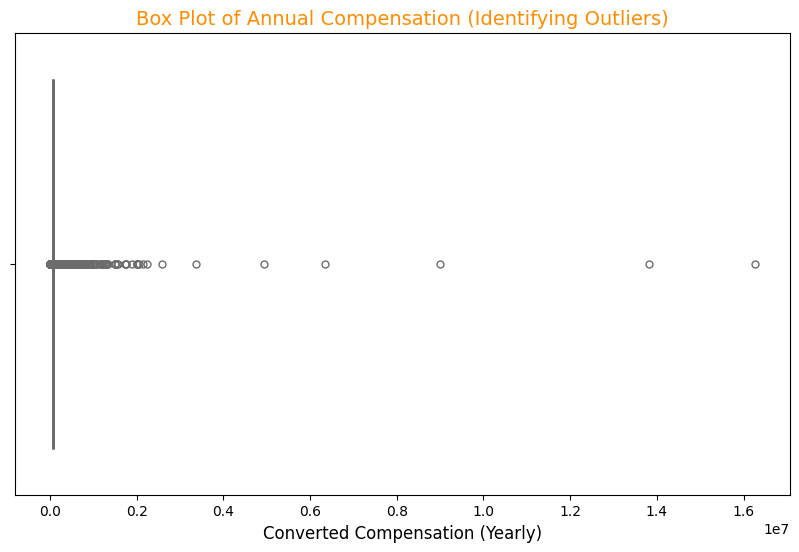

In [14]:
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)].shape[0]
print(f"Interquartile Range (IQR): {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total number of outliers (IQR method): {outliers_count}")

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['ConvertedCompYearly'], color="#FF69B4", fliersize=5, linewidth=2)

plt.title('Box Plot of Annual Compensation (Identifying Outliers)', fontsize=14, color='#FF8C00')
plt.xlabel('Converted Compensation (Yearly)', fontsize=12)
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [15]:
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)].copy()

print(f"Original DataFrame size: {df.shape[0]} rows")
print(f"New DataFrame size (no outliers): {df_no_outliers.shape[0]} rows")
print(f"Percentage of data retained: {(len(df_no_outliers)/len(df))*100:.2f}%")

Original DataFrame size: 65437 rows
New DataFrame size (no outliers): 42039 rows
Percentage of data retained: 64.24%


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


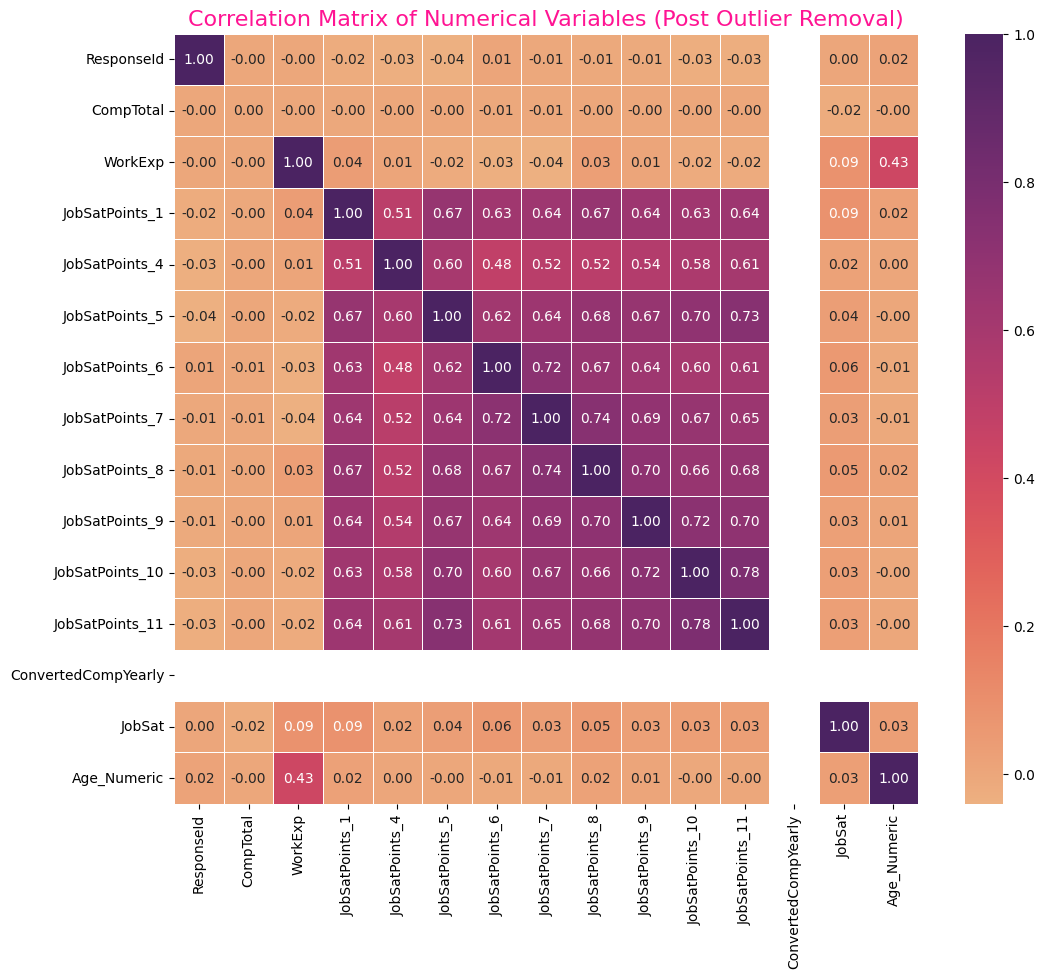

In [17]:
age_mapping = {
    'Unknown': 20,
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

df_no_outliers['Age_Numeric'] = df_no_outliers['Age'].map(age_mapping)

numeric_df = df_no_outliers.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='flare', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Numerical Variables (Post Outlier Removal)', fontsize=16, color='#FF1493')
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
